In [2]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import seaborn as sns #visualisation
import matplotlib.pyplot as plt #visualisation
%matplotlib inline 



Matplotlib is building the font cache; this may take a moment.


In [3]:
df_viviendas = pd.read_csv("viviendas_reto.csv")
df_viviendas.head()

,metros,habitaciones,banios,antiguedad,distancia_centro,precio
0,100.5,4,2.0,5,10.0,2620000
1,43.6,2,1.0,21,3.0,1466000
2,166.3,2,2.0,13,4.2,3536000
3,77.3,3,2.0,50,6.3,1898000
4,112.4,2,1.0,26,25.5,2049000


In [2]:
df_viviendas.isnull().sum()

metros              0
habitaciones        0
banios              6
antiguedad          0
distancia_centro    0
precio              0
dtype: int64

In [3]:
df_viviendas.describe()

,metros,habitaciones,banios,antiguedad,distancia_centro,precio
count,800.000000,800.000000,794.000000,800.00000,800.000000,8.000000e+02
mean,114.775375,2.966250,2.042821,14.81875,6.866750,2.751383e+06
std,44.385040,1.063732,0.937212,9.67253,6.861149,8.322200e+05
min,30.000000,1.000000,1.000000,0.00000,0.300000,8.020000e+05
25%,82.525000,2.000000,1.000000,8.00000,1.975000,2.170000e+06
50%,113.100000,3.000000,2.000000,13.00000,4.700000,2.768500e+06
75%,146.650000,4.000000,3.000000,20.00000,9.600000,3.277500e+06
max,247.100000,5.000000,4.000000,50.00000,35.000000,8.696600e+06


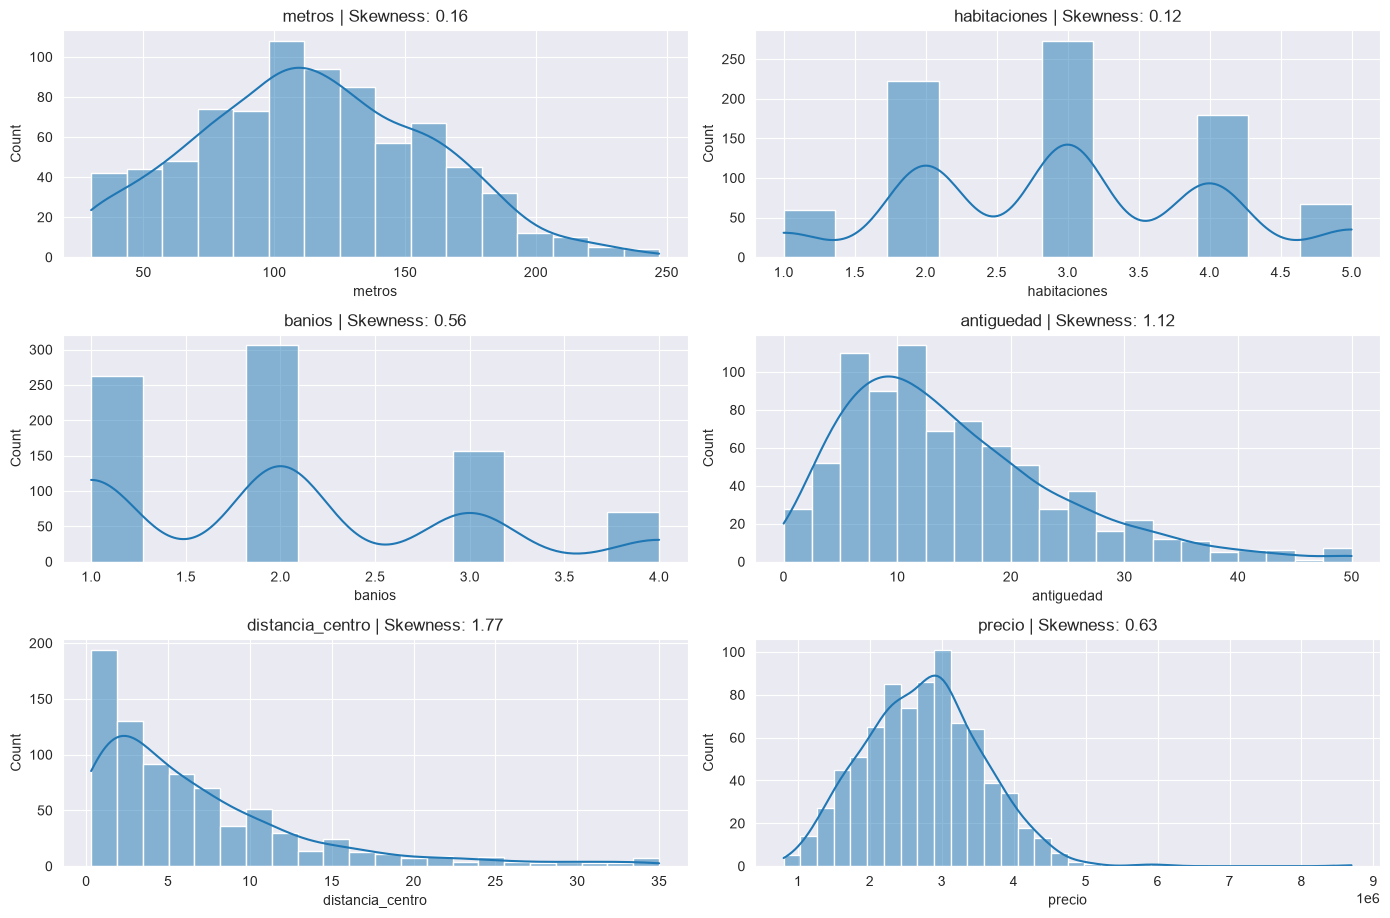

In [4]:
sns.set_style("darkgrid")

numerical_columns = df_viviendas.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, precio in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df_viviendas[precio], kde=True)
    plt.title(f"{precio} | Skewness: {round(df_viviendas[precio].skew(), 2)}")

plt.tight_layout()

plt.savefig("my_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
def boxplots_custom(dataset, columns_list, suptitle=''):
    num_plots = len(columns_list)
    cols = 3
    rows = (num_plots + cols - 1) // cols   # ceiling division

    fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axs = axs.flatten()

    for i, col in enumerate(columns_list):
        sns.boxplot(data=dataset[col], orient='h', ax=axs[i])
        axs[i].set_title(col + ', skewness: ' + str(round(dataset[col].skew(), 2)))

    # Remove unused axes
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


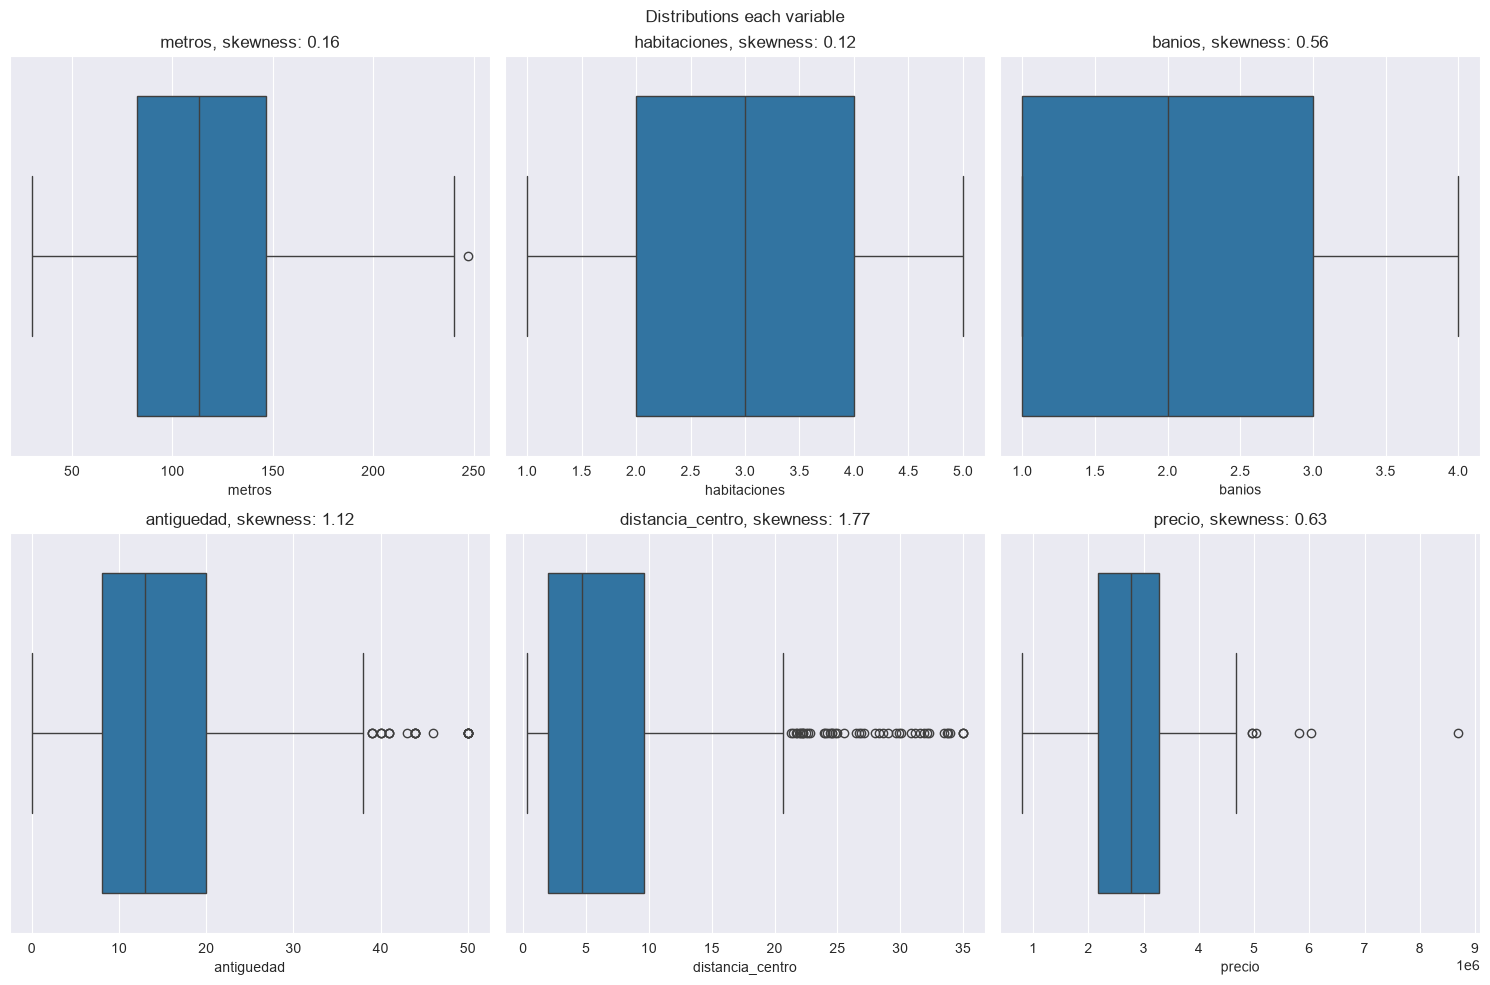

In [7]:
numerical_columns = list(df_viviendas.select_dtypes(include=['float64', 'int64']).columns)
boxplots_custom(dataset=df_viviendas, columns_list=numerical_columns, suptitle='Distributions each variable' )


In [10]:
plt.figure(figsize=(20, 10))

c = df_viviendas[df_viviendas].corr(numeric_only=True)   # Only numeric columns
sns.heatmap(c, cmap="BrBG", annot=True)

plt.savefig("map.png", dpi=300, bbox_inches='tight')
plt.show()

TypeError: Boolean array expected for the condition, not float64

<Figure size 2000x1000 with 0 Axes>